In [2]:
import numpy as np
import adi
import time

def pluto_capture_iq(
    uri="ip:pluto.local",
    center_hz=2.4065e9,
    sample_rate=2_300_000,
    rf_bandwidth=1_000_000,
    gain_mode="manual",        # "manual" or "slow_attack"
    gain_db=8,
    num_samples=2_300_000,     # 1 second at 2.3 MS/s
    warmup_reads=2,
):
    """
    Returns complex64 IQ array of length num_samples (approximately).
    """
    sdr = adi.Pluto(uri)

    # RX configuration
    sdr.rx_lo = int(center_hz)
    sdr.sample_rate = int(sample_rate)
    sdr.rx_rf_bandwidth = int(rf_bandwidth)

    sdr.gain_control_mode_chan0 = gain_mode
    if gain_mode == "manual":
        sdr.rx_hardwaregain_chan0 = float(gain_db)

    # Buffering
    # rx_buffer_size controls how many samples you get per read().
    # Using a moderate chunk size is reliable.
    chunk = 262144
    sdr.rx_buffer_size = chunk

    # Warm up (let LO/filters settle)
    for _ in range(warmup_reads):
        _ = sdr.rx()

    # Capture in chunks
    iq = np.empty(num_samples, dtype=np.complex64)
    got = 0
    while got < num_samples:
        x = sdr.rx().astype(np.complex64)
        n = min(len(x), num_samples - got)
        iq[got:got+n] = x[:n]
        got += n

    return iq

In [3]:
Fs = 2_300_000
iq = pluto_capture_iq(
    uri="ip:pluto.local",
    center_hz=2.405e9,
    sample_rate=Fs,
    rf_bandwidth=1_000_000,
    gain_mode="manual",
    gain_db=20,
    num_samples=Fs * 2,   # 2 seconds
)
print(iq.shape, iq.dtype)

(4600000,) complex64


In [4]:
import matplotlib.pyplot as plt

def quick_mag_plot(iq, Fs, seconds=0.05):
    n = int(Fs * seconds)
    m = np.abs(iq[:n])
    t = np.arange(len(m)) / Fs
    plt.figure()
    plt.plot(t*1e3, m)
    plt.xlabel("Time (ms)")
    plt.ylabel("|IQ|")
    plt.show()

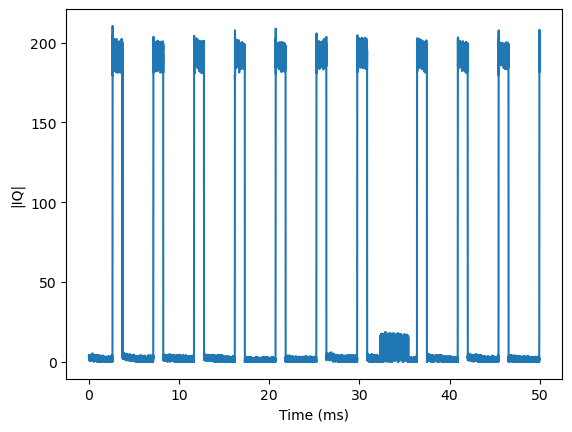

In [5]:
quick_mag_plot(iq, Fs)

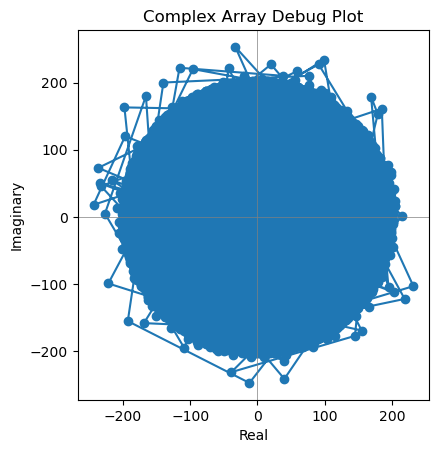

In [6]:
import numpy as np
import matplotlib.pyplot as plt

z = iq[::100]

plt.plot(z.real, z.imag, marker='o')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.gca().set_aspect('equal')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Complex Array Debug Plot")
plt.show()

In [7]:
import numpy as np

#iq = ... # complex numpy array
phase = np.angle(iq)
dphase = np.diff(np.unwrap(phase))
f_inst = np.mod(dphase + np.pi, 2*np.pi) - np.pi


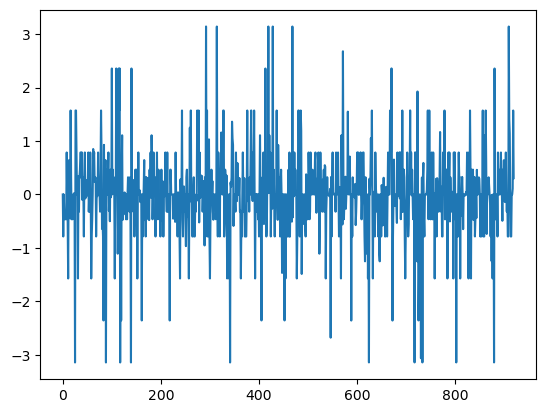

In [12]:
plt.plot(f_inst[::5000])

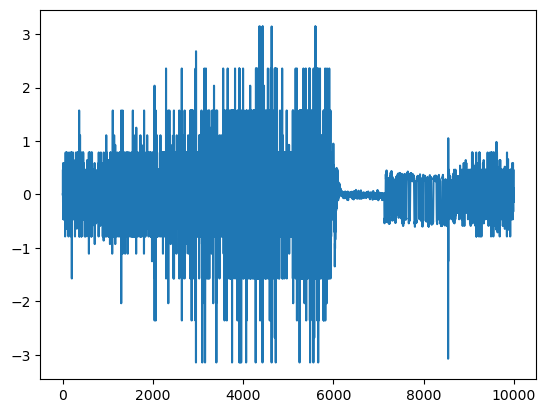

In [15]:
plt.plot(f_inst[:10000])

In [16]:
import numpy as np

def iq_to_magdb(iq, eps=1e-12):
    """
    Convert IQ samples to magnitude in dB.

    Parameters
    ----------
    iq : array-like
        Complex IQ samples (I + 1j*Q) or shape (N, 2) [I, Q].
    eps : float
        Small value to avoid log(0).

    Returns
    -------
    mag_db : np.ndarray
        Magnitude in dB.
    """
    iq = np.asarray(iq)

    # If IQ is given as separate I/Q columns
    if iq.ndim == 2 and iq.shape[1] == 2:
        I = iq[:, 0]
        Q = iq[:, 1]
        mag = np.sqrt(I**2 + Q**2)
    else:
        # IQ given as complex
        mag = np.abs(iq)

    mag_db = 20 * np.log10(mag + eps)
    return mag_db


In [17]:
# Complex IQ samples
mag_db = iq_to_magdb(iq)
print(mag_db)

# Separate I/Q
# iq_iq = np.array([[1, 1], [0.5, 0.5], [0.1, 0.1]])
# mag_db = iq_to_magdb(iq_iq)
# print(mag_db)


[9.0309    9.0309    9.0309    ... 6.9897003 9.542425  9.542425 ]


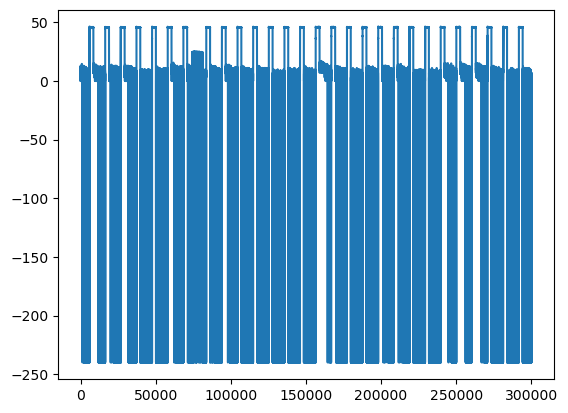

In [22]:
plt.plot(mag_db[:300000])

In [23]:
# GFSK / 2-FSK demodulator for 250 kbps
# Input: URH complex32s (float32 I,Q interleaved)
# Output: NRZ bitstream
# Sample rate: 4 MS/s

import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# -------------------------
# PARAMETERS
# -------------------------
FS = 4_000_000        # sample rate (Hz)
RS = 250_000          # symbol rate (baud)
SPS = FS / RS         # samples per symbol (16.0)
LPF_CUTOFF = 350_000  # Hz (tune 250k–400k if needed)
MM_GAIN = 0.01        # clock recovery loop gain
INVERT_BITS = False  # flip if bits look inverted

# -------------------------
# LOAD URH complex32s
# -------------------------
def load_urh_complex32s(filename):
    raw = np.fromfile(filename, dtype=np.float32)
    iq = raw[0::2] + 1j * raw[1::2]
    return iq

# -------------------------
# QUADRATURE FM DEMOD
# -------------------------
def quad_demod(iq):
    return np.angle(iq[1:] * np.conj(iq[:-1]))

# -------------------------
# LOWPASS FILTER
# -------------------------
def lowpass(x, cutoff, fs, taps=129):
    fir = signal.firwin(taps, cutoff, fs=fs)
    return signal.lfilter(fir, 1.0, x)

# -------------------------
# MUELLER & MULLER CLOCK RECOVERY
# -------------------------
def mueller_muller(x, sps, gain):
    out = []
    mu = 0.0
    i = 0

    last_sample = 0.0
    last_decision = 0.0

    while i + 2 < len(x):
        # Linear interpolation
        s = (1 - mu) * x[i] + mu * x[i + 1]

        decision = 1.0 if s >= 0 else -1.0
        e = (decision - last_decision) * last_sample

        mu += sps + gain * e
        step = int(np.floor(mu))
        mu -= step
        i += step

        out.append(s)

        last_sample = s
        last_decision = decision

    return np.array(out)

# -------------------------
# NRZ SLICER
# -------------------------
def nrz(bits, invert=False):
    b = (bits >= 0).astype(np.uint8)
    if invert:
        b ^= 1
    return b

# -------------------------
# FULL PIPELINE
# -------------------------
def gfsk_demod(filename):
    iq = load_urh_complex32s(filename)

    demod = quad_demod(iq)
    demod = lowpass(demod, LPF_CUTOFF, FS)
    demod -= np.mean(demod)  # DC removal

    symbols = mueller_muller(demod, SPS, MM_GAIN)
    bits = nrz(symbols, INVERT_BITS)

    return bits, symbols, demod

# -------------------------
# RUN
# -------------------------
# CHANGE THIS TO YOUR FILE
filename = "ls-OFF-4M-p6M.complex32s"

bits, symbols, demod = gfsk_demod(filename)

print("First 200 bits:")
print(bits[:200])

# -------------------------
# QUICK DEBUG PLOTS
# -------------------------
plt.figure(figsize=(12,4))
plt.plot(demod[:2000])
plt.title("GFSK discriminator output")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.stem(bits[:200], use_line_collection=True)
plt.title("Recovered NRZ bits")
plt.ylim(-0.2, 1.2)
plt.grid(True)
plt.show()


/tmp/ipykernel_1922227/3568178132.py:25: RuntimeWarning: invalid value encountered in multiply
  iq = raw[0::2] + 1j * raw[1::2]
/tmp/ipykernel_1922227/3568178132.py:25: RuntimeWarning: invalid value encountered in add
  iq = raw[0::2] + 1j * raw[1::2]
/tmp/ipykernel_1922227/3568178132.py:32: RuntimeWarning: overflow encountered in multiply
  return np.angle(iq[1:] * np.conj(iq[:-1]))
/tmp/ipykernel_1922227/3568178132.py:32: RuntimeWarning: invalid value encountered in multiply
  return np.angle(iq[1:] * np.conj(iq[:-1]))


ValueError: cannot convert float NaN to integer

RAW I stats: {'name': 'I', 'count': 42958848, 'finite_%': np.float64(52.41691769760679), 'nan': 20434533, 'inf': 6611, 'min': -inf, 'max': 1.432414069557853e-33}
RAW Q stats: {'name': 'Q', 'count': 42958848, 'finite_%': np.float64(52.424601795653366), 'nan': 20431303, 'inf': 6540, 'min': -inf, 'max': 1.8777960221149556e-33}


/tmp/ipykernel_1922227/3789852739.py:49: RuntimeWarning: overflow encountered in square
  p = np.mean(np.abs(iq)**2)


Demod stats: finite% = 100.0 len = 42958847
Sym len: 2684958 Bits len: 2684958
First 200 bits:
[1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0
 1 1 0 0 1 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 0
 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0
 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 0 0 1 0 0 1 1 1 0 1 1 1 0 1
 1 0 1 1 0 0 1 1 1 0 1 1 0 1 1]


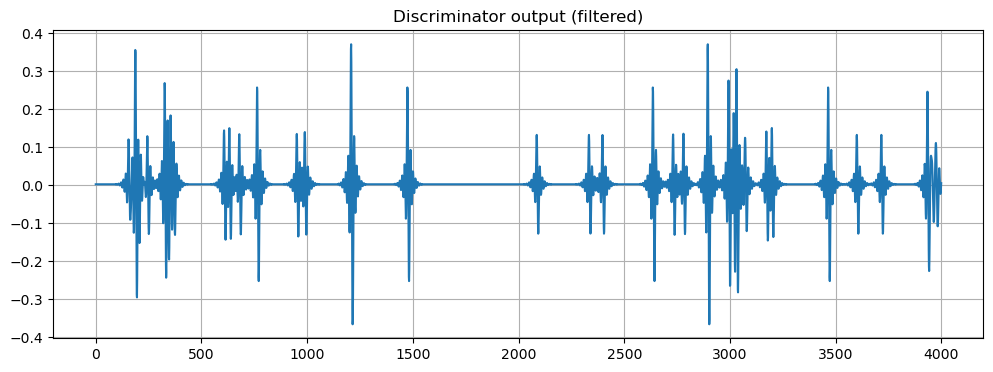

TypeError: stem() got an unexpected keyword argument 'use_line_collection'

<Figure size 1200x300 with 0 Axes>

In [24]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# -------------------------
# PARAMETERS
# -------------------------
FS = 4_000_000
RS = 250_000
SPS = FS / RS          # 16.0
LPF_CUTOFF = 350_000   # tune 250k–400k
MM_GAIN = 0.01
INVERT_BITS = False

# -------------------------
# LOAD URH complex32s (float32 I,Q interleaved)
# -------------------------
def load_urh_complex32s(filename):
    raw = np.fromfile(filename, dtype=np.float32)
    if raw.size % 2 != 0:
        raw = raw[:-1]

    I = raw[0::2]
    Q = raw[1::2]

    # Diagnostics
    def stats(name, x):
        finite = np.isfinite(x)
        return {
            "name": name,
            "count": x.size,
            "finite_%": 100.0 * finite.mean(),
            "nan": int(np.isnan(x).sum()),
            "inf": int(np.isinf(x).sum()),
            "min": float(np.nanmin(x)),
            "max": float(np.nanmax(x)),
        }

    print("RAW I stats:", stats("I", I))
    print("RAW Q stats:", stats("Q", Q))

    # Replace non-finite with 0
    I = np.nan_to_num(I, nan=0.0, posinf=0.0, neginf=0.0)
    Q = np.nan_to_num(Q, nan=0.0, posinf=0.0, neginf=0.0)

    iq = I + 1j * Q

    # Optional: normalize to avoid huge scaling issues (won't hurt)
    p = np.mean(np.abs(iq)**2)
    if p > 0:
        iq = iq / np.sqrt(p)

    return iq

# -------------------------
# STABLE FM DEMOD (phase unwrap + diff)
# -------------------------
def quad_demod_stable(iq):
    # angle -> unwrap -> diff gives instantaneous phase change
    phase = np.unwrap(np.angle(iq))
    dphi = np.diff(phase)

    # Clean any non-finite just in case
    dphi = np.nan_to_num(dphi, nan=0.0, posinf=0.0, neginf=0.0)
    return dphi

# -------------------------
# LOWPASS FILTER
# -------------------------
def lowpass(x, cutoff, fs, taps=129):
    fir = signal.firwin(taps, cutoff, fs=fs)
    y = signal.lfilter(fir, 1.0, x)
    return y

# -------------------------
# MUELLER & MULLER CLOCK RECOVERY (NaN-safe)
# -------------------------
def mueller_muller(x, sps, gain):
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    out = []
    mu = 0.0
    i = 0
    last_sample = 0.0
    last_decision = 0.0

    # Hard limit loop to avoid infinite loops if something goes wrong
    max_iters = len(x)

    iters = 0
    while i + 2 < len(x) and iters < max_iters:
        iters += 1

        s = (1 - mu) * x[i] + mu * x[i + 1]

        decision = 1.0 if s >= 0 else -1.0
        e = (decision - last_decision) * last_sample

        mu_next = mu + sps + gain * e

        # Guard against NaN/Inf
        if not np.isfinite(mu_next):
            # reset the loop if it blows up
            mu_next = 0.0

        mu = mu_next
        step = int(np.floor(mu))
        mu -= step
        i += step

        out.append(s)
        last_sample = s
        last_decision = decision

    return np.array(out, dtype=np.float64)

# -------------------------
# NRZ SLICER
# -------------------------
def nrz_slicer(sym, invert=False):
    bits = (sym >= 0).astype(np.uint8)
    if invert:
        bits ^= 1
    return bits

# -------------------------
# FULL PIPELINE
# -------------------------
def gfsk_demod(filename):
    iq = load_urh_complex32s(filename)

    demod = quad_demod_stable(iq)
    demod = lowpass(demod, LPF_CUTOFF, FS)
    demod -= np.mean(demod)

    # Final cleanup
    demod = np.nan_to_num(demod, nan=0.0, posinf=0.0, neginf=0.0)

    sym = mueller_muller(demod, SPS, MM_GAIN)
    bits = nrz_slicer(sym, invert=INVERT_BITS)

    print("Demod stats: finite% =", 100*np.isfinite(demod).mean(), "len =", len(demod))
    print("Sym len:", len(sym), "Bits len:", len(bits))

    return bits, sym, demod




In [ ]:
# -------------------------
# RUN
# -------------------------
filename = "ls-OFF-4M-p6M.complex32s"  # <-- your file
bits, sym, demod = gfsk_demod(filename)

print("First 200 bits:")
print(bits[:200])



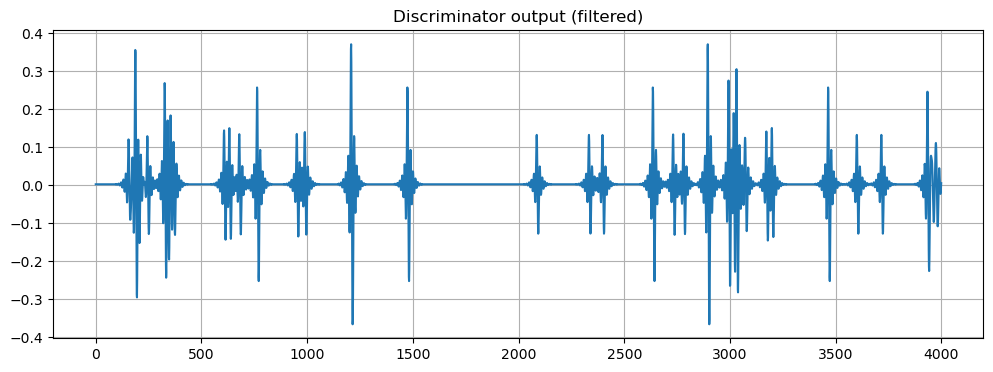

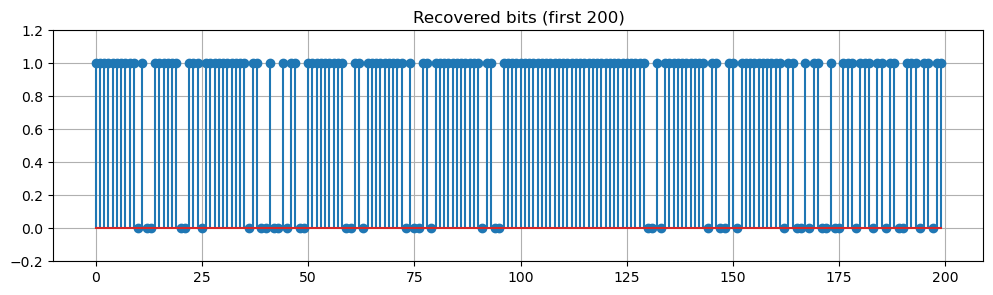

In [29]:
# -------------------------
# PLOTS
# -------------------------
plt.figure(figsize=(12,4))
plt.plot(demod[:4000])
plt.title("Discriminator output (filtered)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,3))
plt.stem(bits[:200])
plt.title("Recovered bits (first 200)")
plt.ylim(-0.2, 1.2)
plt.grid(True)
plt.show()

In [25]:
bits[:100]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1], dtype=uint8)

In [26]:
sym[:10]

array([0.00211042, 0.00211042, 0.00211042, 0.00211042, 0.00211042,
       0.00211042, 0.00274428, 0.00104985, 0.00111634, 0.02052322])

In [28]:
bits.shape

(2684958,)

In [30]:
import numpy as np

def find_bit_pattern(bitstream, pattern):
    """
    bitstream: array-like of 0/1 (list, numpy array, etc.)
    pattern: string like '101010' or list/array of 0/1

    Returns:
        count: number of occurrences
        indices: list of start indices
    """
    # Convert pattern to numpy array of ints
    if isinstance(pattern, str):
        pat = np.array([int(b) for b in pattern], dtype=np.uint8)
    else:
        pat = np.array(pattern, dtype=np.uint8)

    bits = np.asarray(bitstream, dtype=np.uint8)

    pat_len = len(pat)
    matches = []

    for i in range(len(bits) - pat_len + 1):
        if np.array_equal(bits[i:i + pat_len], pat):
            matches.append(i)

    return len(matches), matches

# -------------------------
# EXAMPLE USAGE
# -------------------------
pattern = "11100010000111101010101001011110111110110000111101111110010111110"

count, positions = find_bit_pattern(bits, pattern)

print("Pattern length:", len(pattern))
print("Occurrences:", count)
print("Start indices:", positions[:10])  # first 10 if many


Pattern length: 65
Occurrences: 0
Start indices: []


In [36]:
import numpy as np

def load_complex16s_iq(filename, scale=True):
    """
    Load interleaved int16 IQ: I0, Q0, I1, Q1, ...
    Returns complex64 normalized to ~[-1,1] if scale=True.
    """
    raw = np.fromfile(filename, dtype=np.int16)
    raw = raw[: (raw.size // 2) * 2]  # even length

    I = raw[0::2].astype(np.float32)
    Q = raw[1::2].astype(np.float32)

    if scale:
        # int16 full-scale is 32768 (symmetric-ish)
        I /= 32768.0
        Q /= 32768.0

    iq = I + 1j * Q
    return iq

# quick sanity check
fn = "ls-OFF-4M-p6M.complex32s"
iq = load_complex16s_iq(fn)

print("IQ dtype:", iq.dtype, "len:", len(iq))
print("finite%:", 100*np.isfinite(iq.real).mean(), 100*np.isfinite(iq.imag).mean())
print("I range:", float(iq.real.min()), float(iq.real.max()))
print("Q range:", float(iq.imag.min()), float(iq.imag.max()))


IQ dtype: complex64 len: 85917696
finite%: 100.0 100.0
I range: -0.072784423828125 0.072296142578125
Q range: -0.072479248046875 0.07415771484375


In [1]:
# Pluto/URH "complex32s" (actually interleaved signed int16 IQ) -> burst detect -> GFSK demod -> bits -> hex
# Fs=4e6, Rs=250e3
# Decodes ONLY inside detected bursts (noise suppression + quality gate)

import numpy as np
from dataclasses import dataclass
from fractions import Fraction

try:
    from scipy.signal import firwin, lfilter, resample_poly
except ImportError as e:
    raise ImportError("This notebook needs scipy (scipy.signal). Install scipy or ask for a pure-numpy version.") from e


# =============================================================================
# USER SETTINGS (tune these)
# =============================================================================
FS = 4_000_000            # sample rate Hz
RS = 250_000              # symbol rate (known)
TARGET_SPS = 4            # resample to RS*TARGET_SPS = 1 MHz
LPF_CUTOFF_HZ = 350_000   # discriminator LPF (try 250k..450k)
FIR_TAPS = 129

# Burst detection / noise suppression
MAG_SMOOTH_MS = 0.20      # envelope smoothing (ms)
THRESH_DB = 10.0          # threshold above noise floor (dB)
HYST_DB = 3.0             # hysteresis (dB)
MIN_LEN_MS = 0.60         # minimum burst length (ms)
PAD_MS = 0.20             # pad around burst edges (ms)

# Decode acceptance (reject noise-only "decodes")
MIN_SCORE = 2.0           # increase (3..5) if too many false decodes

# Misc
INVERT_BITS = False       # flip if your preamble looks inverted
MAX_RESAMPLE_DEN = 512    # bound for rational approximation


# =============================================================================
# Types
# =============================================================================
@dataclass
class Burst:
    start: int  # inclusive
    end: int    # exclusive


# =============================================================================
# Loader: your ".complex32s" is actually interleaved signed int16 IQ (I,Q,I,Q,... little-endian)
# =============================================================================
def load_iq_int16_interleaved(filename: str, normalize_power: bool = True) -> np.ndarray:
    raw = np.fromfile(filename, dtype=np.int16)
    raw = raw[: (raw.size // 2) * 2]

    I = raw[0::2].astype(np.float32) / 32768.0
    Q = raw[1::2].astype(np.float32) / 32768.0

    # Clean non-finite in each component (compatible with older numpy behavior)
    I = np.nan_to_num(I, nan=0.0, posinf=0.0, neginf=0.0)
    Q = np.nan_to_num(Q, nan=0.0, posinf=0.0, neginf=0.0)

    iq = I + 1j * Q
    iq = iq.astype(np.complex64, copy=False)

    if normalize_power:
        p = np.mean((I*I + Q*Q))  # faster than abs()**2
        if p > 0:
            iq = iq / np.sqrt(p)

    return iq


# =============================================================================
# Burst detection (smoothing + hysteresis + min length + padding)
# =============================================================================
def moving_average(x: np.ndarray, n: int) -> np.ndarray:
    if n <= 1:
        return x.astype(np.float64, copy=False)
    w = np.ones(n, dtype=np.float64) / n
    return np.convolve(x.astype(np.float64, copy=False), w, mode="same")


def detect_bursts(iq: np.ndarray, fs: float,
                  thresh_db: float = THRESH_DB,
                  hyst_db: float = HYST_DB,
                  min_len_ms: float = MIN_LEN_MS,
                  pad_ms: float = PAD_MS,
                  smooth_ms: float = MAG_SMOOTH_MS):
    """
    Returns: bursts(list[Burst]), env(smooth mag), thr_on, thr_off, noise_est
    """
    mag = np.abs(iq)
    smooth_n = max(1, int((smooth_ms / 1000.0) * fs))
    env = moving_average(mag, smooth_n)

    # Robust noise floor estimate (lower percentile)
    noise = np.percentile(env, 20.0) + 1e-12

    thr_on = noise * (10 ** (thresh_db / 20.0))
    thr_off = noise * (10 ** ((thresh_db - hyst_db) / 20.0))

    bursts_raw = []
    in_burst = False
    s = 0

    for i in range(len(env)):
        if not in_burst:
            if env[i] > thr_on:
                in_burst = True
                s = i
        else:
            if env[i] < thr_off:
                in_burst = False
                bursts_raw.append((s, i))

    if in_burst:
        bursts_raw.append((s, len(env)))

    min_len = int((min_len_ms / 1000.0) * fs)
    pad = int((pad_ms / 1000.0) * fs)

    bursts = []
    for s, e in bursts_raw:
        if (e - s) < min_len:
            continue
        ss = max(0, int(s - pad))
        ee = min(len(iq), int(e + pad))  # end-exclusive
        bursts.append(Burst(ss, ee))

    return bursts, env, thr_on, thr_off, noise


# =============================================================================
# GFSK/2-FSK demod (quadrature discriminator) + LPF
# =============================================================================
def fm_discriminator(iq: np.ndarray) -> np.ndarray:
    y = np.angle(np.conj(iq[:-1]) * iq[1:])
    # Clean to avoid NaN propagation
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    return y.astype(np.float32, copy=False)


def lowpass_fir(x: np.ndarray, fs: float, cutoff_hz: float, numtaps: int = FIR_TAPS) -> np.ndarray:
    taps = firwin(numtaps, cutoff_hz, fs=fs)
    return lfilter(taps, 1.0, x)


# =============================================================================
# Symbol phase picking + slicing + bytes
# =============================================================================
def pick_best_symbol_phase(sym: np.ndarray, sps: int):
    best_phase = 0
    best_score = -1.0
    best_thr = 0.0

    for ph in range(sps):
        z = sym[ph::sps]
        if z.size < 200:
            continue

        thr = np.median(z)
        b0 = z[z <= thr]
        b1 = z[z > thr]
        if b0.size < 50 or b1.size < 50:
            continue

        m0, m1 = np.mean(b0), np.mean(b1)
        v0, v1 = np.var(b0), np.var(b1)
        score = abs(m1 - m0) / (np.sqrt(v0 + v1) + 1e-12)

        if score > best_score:
            best_score = score
            best_phase = ph
            best_thr = thr

    return best_phase, best_thr, best_score


def slice_bits(sym: np.ndarray, sps: int, phase: int, thr: float, invert: bool = False) -> np.ndarray:
    z = sym[phase::sps]
    bits = (z > thr).astype(np.uint8)
    if invert:
        bits ^= 1
    return bits


def bits_to_bytes(bits: np.ndarray, msb_first: bool = True) -> bytes:
    n = (len(bits) // 8) * 8
    b = bits[:n].reshape(-1, 8)
    if msb_first:
        vals = (b * (1 << np.arange(7, -1, -1))).sum(axis=1)
    else:
        vals = (b * (1 << np.arange(0, 8))).sum(axis=1)
    return bytes(vals.tolist())


# =============================================================================
# Main: decode ONLY inside detected bursts (noise suppression)
# =============================================================================
def demod_bursts_to_hex(filename: str,
                        Fs: float = FS,
                        symrate: float = RS,
                        target_sps: int = TARGET_SPS,
                        lp_cutoff_hz: float = LPF_CUTOFF_HZ,
                        min_score: float = MIN_SCORE,
                        invert_bits: bool = INVERT_BITS):
    """
    Returns list of dicts with burst info + hex + raw bits.
    """
    iq = load_iq_int16_interleaved(filename, normalize_power=True)

    bursts, env, thr_on, thr_off, noise = detect_bursts(
        iq, Fs,
        thresh_db=THRESH_DB,
        hyst_db=HYST_DB,
        min_len_ms=MIN_LEN_MS,
        pad_ms=PAD_MS,
        smooth_ms=MAG_SMOOTH_MS
    )

    print(f"Noise estimate: {noise:.4g}")
    print(f"Thr_on: {thr_on:.4g}  Thr_off: {thr_off:.4g}")
    print(f"Detected bursts: {len(bursts)}")

    Fs_rs = symrate * int(target_sps)
    frac = Fraction(int(round(Fs_rs)), int(round(Fs))).limit_denominator(MAX_RESAMPLE_DEN)
    up, dn = frac.numerator, frac.denominator
    print(f"Resample ratio: up={up}, dn={dn}  (target Fs_rs={Fs_rs:.0f} Hz)")

    out = []
    for i, b in enumerate(bursts):
        x = iq[b.start:b.end]

        # Discriminator at Fs
        dphi = fm_discriminator(x)

        # LPF (noise suppression for demod)
        dphi_f = lowpass_fir(dphi, Fs, cutoff_hz=lp_cutoff_hz, numtaps=FIR_TAPS)
        dphi_f = dphi_f - np.mean(dphi_f)
        dphi_f = np.nan_to_num(dphi_f, nan=0.0, posinf=0.0, neginf=0.0)

        # Resample to Fs_rs (integer SPS)
        sym = resample_poly(dphi_f, up, dn)
        sym = np.nan_to_num(sym, nan=0.0, posinf=0.0, neginf=0.0)

        # Pick best sampling phase and slice
        ph, thr, score = pick_best_symbol_phase(sym, int(target_sps))

        # Quality gate: reject noise-only windows
        if (not np.isfinite(score)) or score < min_score:
            continue

        bits = slice_bits(sym, int(target_sps), ph, thr, invert=invert_bits)

        out.append({
            "burst_index": i,
            "start_s": b.start / Fs,
            "len_s": (b.end - b.start) / Fs,
            "score": float(score),
            "phase": int(ph),
            "thr": float(thr),
            "bits_len": int(len(bits)),
            "hex_msb": bits_to_bytes(bits, msb_first=True).hex(),
            "hex_lsb": bits_to_bytes(bits, msb_first=False).hex(),
            "bits": bits,
        })

    print(f"Decoded bursts (passed quality gate): {len(out)}")
    return out


In [2]:
# =============================================================================
# Example run
# =============================================================================
filename = "ls-OFF-4M-p6M.complex32s"
results = demod_bursts_to_hex(filename)
if results:
    r = results[0]
    print("First decoded burst:")
    print("score:", r["score"], "bits_len:", r["bits_len"])
    print("hex_msb:", r["hex_msb"][:120], "...")
    print("hex_lsb:", r["hex_lsb"][:120], "...")

Noise estimate: 0.5766
Thr_on: 1.824  Thr_off: 1.291
Detected bursts: 0
Resample ratio: up=1, dn=4  (target Fs_rs=1000000 Hz)
Decoded bursts (passed quality gate): 0


In [3]:
results

[]